
# Brain Tumor Classification with Transfer Learning (ResNet18)

This notebook trains a transfer learning classifier on a 4‑class Brain MRI dataset
using ResNet18. It includes:

- ImageNet normalization and `224×224` inputs
- Partial fine‑tuning (unfreeze final layers)
- Class balancing (weighted loss)
- Data augmentation
- Learning rate scheduler + Early stopping
  
Specifically, we'll use networks trained on [ImageNet](http://www.image-net.org/) [available from torchvision](http://pytorch.org/docs/0.3.0/torchvision/models.html). ImageNet is a massive dataset with over 1 million labeled images in 1000 categories. 

With `torchvision.models` you can download these pre-trained networks and use them in your applications. We'll include `models` in our imports now.


In [42]:

import os
import random
from collections import Counter
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Most of the pretrained models require the input to be 224x224 images. Also, we'll need to match the normalization used when the models were trained. Each color channel was normalized separately, the means are `[0.485, 0.456, 0.406]` and the standard deviations are `[0.229, 0.224, 0.225]`.

### Load and Augment the Data

The brain tumor MRI dataset is available [here](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset). If you are working locally, download the data, unzip it and place it in a subfolder `data` of your working directory.



In [43]:
# Data paths (expected structure: Training/<class>/..., Testing/<class>/...)
train_root = '/data/brain_tumor/Training'
test_root  = '/data/brain_tumor/Testing'

# ImageNet normalization & 224x224 inputs for transfer learning
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load datasets (ImageFolder expects subfolders per class)
train_full = datasets.ImageFolder(train_root, transform=train_tf)
test_data  = datasets.ImageFolder(test_root,  transform=eval_tf)

classes = train_full.classes
num_classes = len(classes)
print("Classes:", classes)
print("Train images (full):", len(train_full))
print("Test images:", len(test_data))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images (full): 5712
Test images: 1311


In [44]:
# Create a stratified train/val split from 'Training'
targets = np.array(train_full.targets)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros_like(targets), targets))
train_data = Subset(train_full, train_idx)

# For validation we need eval transforms (no augmentation):
val_full = datasets.ImageFolder(train_root, transform=eval_tf)
val_data = Subset(val_full, val_idx)

print("Train subset:", len(train_data), " | Val subset:", len(val_data))

# Compute class counts on the *train subset*
train_targets = targets[train_idx]
class_counts = Counter(train_targets.tolist())
print("Train class counts:", dict(class_counts))

Train subset: 4569  | Val subset: 1143
Train class counts: {1: 1071, 2: 1276, 0: 1057, 3: 1165}


In [45]:

# Weighted loss (inverse frequency) helps class imbalance
weights_ce = torch.tensor([1.0 / class_counts[c] for c in range(num_classes)], dtype=torch.float32).to(device)

# Also balance batches via WeightedRandomSampler
sample_weights = np.array([1.0 / class_counts[t] for t in train_targets])
train_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)


### Visualize a Batch of Training Data

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.0792594].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


(3, 224, 224)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7154248].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6021352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping inp

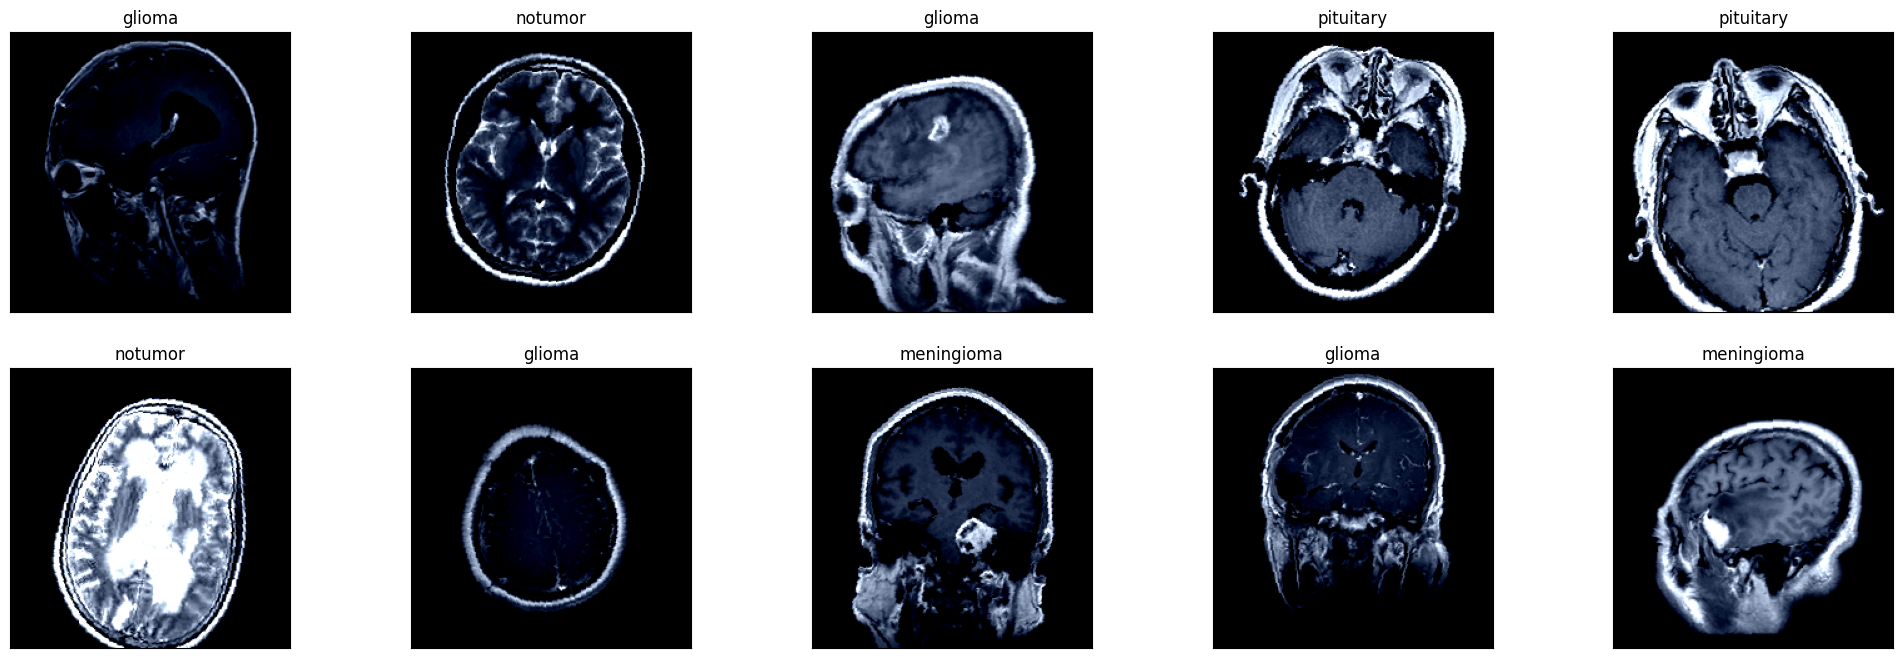

In [47]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 8))
# display 10 images
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

    # take a look at the shape of one image
    if idx == 0:
        print(images[idx].shape) # we have 3 channels (RGB), even though images appear grayscale! 

## Transfer Learning 

We can load in a model such as ResNet18. Let's print out the model architecture so we can see what's going on.

In [48]:

# Build model: ResNet18 with partial unfreezing (layer4 + fc)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

This model is built out of two main parts, the features and the classifier. The features part is a stack of convolutional layers and overall works as a feature detector that can be fed into a classifier. The classifier part is a single fully-connected layer `(fc): Linear(in_features=512, out_features=1000)`. This layer was trained on the ImageNet dataset, so it won't work for our specific problem. That means we need to replace the classifier, but the features will work perfectly on their own. In general, I think about pre-trained networks as amazingly good feature detectors that can be used as the input for simple feed-forward classifiers.

In [49]:

# Freeze everything first
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last residual blocks (layer3+4) and classifier
for name, p in model.named_parameters():
    if name.startswith('layer3') or name.startswith('layer4') or name.startswith('fc'):
        p.requires_grad = True

# Replace classifier for our problem
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**TODO:** What is the most important change here (which code snippet)? Why can't we just fine-tune the original Resnet model on our dataset?

**ANSWER:** Resnet was trained on ImageNet, which has 1000 classes, but we only have 4 classes here. So the most important change is `nn.Linear(in_features, 4)` - the net should output 4 classes instead of 1000.

With our model built, we need to train the classifier. However, now we're using a **really deep** neural network. If you try to train this on a CPU like normal, it will take a long, long time. Instead, we're going to use the GPU to do the calculations. The linear algebra computations are done in parallel on the GPU leading to 100x increased training speeds. It's also possible to train on multiple GPUs, further decreasing training time.

PyTorch, along with pretty much every other deep learning framework, uses [CUDA](https://developer.nvidia.com/cuda-zone) to efficiently compute the forward and backwards passes on the GPU. In PyTorch, you move your model parameters and other tensors to the GPU memory using `model.to('cuda')`. You can move them back from the GPU with `model.to('cpu')` which you'll commonly do when you need to operate on the network output outside of PyTorch. As a demonstration of the increased speed, I'll compare how long it takes to perform a forward and backward pass with and without a GPU.

In [50]:
import time

for device in ['cpu', 'cuda']:

    if not torch.cuda.is_available():
        train_on_gpu = False
        break

    train_on_gpu = True

    criterion = nn.NLLLoss()
    # Only train the classifier parameters, feature parameters are frozen
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    model.to(device)

    for ii, (inputs, labels) in enumerate(train_loader):

        # Move input and label tensors to the GPU
        inputs, labels = inputs.to(device), labels.to(device)

        start = time.time()

        outputs = model.forward(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if ii==3:
            break
        
    print(f"Device = {device}; Time per batch: {(time.time() - start)/3:.3f} seconds")

Device = cpu; Time per batch: 1.635 seconds
Device = cuda; Time per batch: 0.033 seconds


You can write device agnostic code which will automatically use CUDA if it's enabled like so:
```python
# at beginning of the script
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

...

# then whenever you get a new Tensor or Module
# this won't copy if they are already on the desired device
input = data.to(device)
model = MyModule(...).to(device)
```

From here, I'll let you finish training the model. The process is the same as before except now your model is much more powerful. You should get better than 95% accuracy easily.

**TODO:** Train a pretrained model to classify the images. Continue with the ResNet model, or try another architecture. Make sure you are only training the classifier and the parameters for the features part are frozen. Print the train loss, valid loss and valid accuracy repeatedly to check for convergence. 

**HINT:** Complete the following steps:

- Choose the device
- Define the model, e.g. DenseNet, like above
- Freeze the parameters and define a classifier like above
- Define loss and optimizer, but only optimize the classifier parameters
- Move the model to the device
- Implement and run the train loop


In [51]:
# YOUR CODE HERE
# Define loss function with class weights
criterion = nn.CrossEntropyLoss(weight=weights_ce)

# Only optimize the unfrozen parameters
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

# Reduce LR if val loss plateaus
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping helper
import copy
early_stopping_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_wts = copy.deepcopy(model.state_dict())


In [52]:
epochs = 2 # we only do a few epochs here for brevity
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_loss = running_loss / max(1, len(train_loader))
    val_loss = val_loss / max(1, len(val_loader))
    val_acc = 100.0 * correct / max(1, total)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")
            break

# Load best weights
model.load_state_dict(best_wts)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Epoch 01/2 | Train Loss: 0.3060 | Val Loss: 0.1540 | Val Acc: 95.10% | LR: 0.000100
Epoch 02/2 | Train Loss: 0.1278 | Val Loss: 0.1104 | Val Acc: 96.41% | LR: 0.000100
Training complete. Best val loss: 0.1104
Runtime training: 635.59 seconds


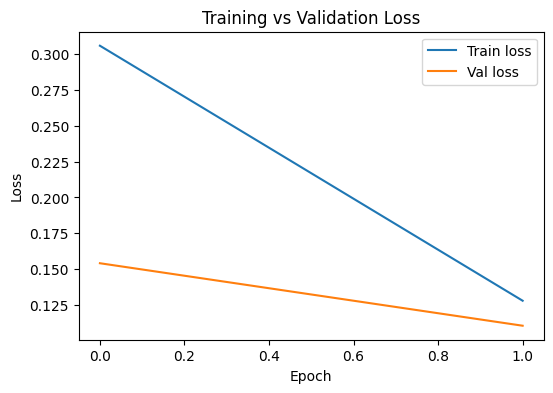

In [53]:

plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


## Test the Trained Network

**TODO:** Test your trained model on previously unseen data! What is the best test accuracy you can achieve?

In [54]:
# YOUR CODE HERE
# --- Evaluate on Test Set ---
model.eval()
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100.0 * test_correct / max(1, test_total)
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 96.26%


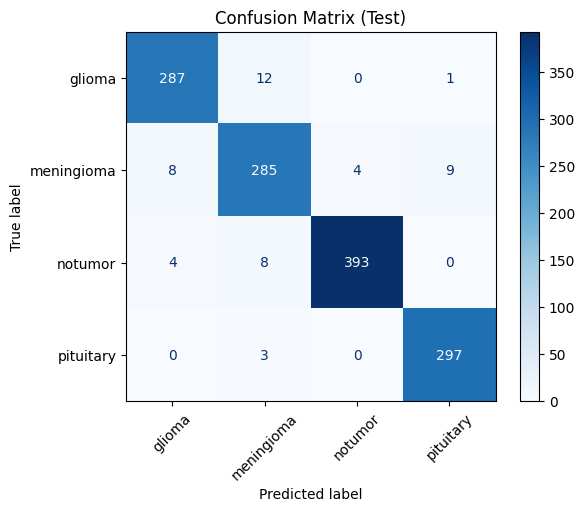

              precision    recall  f1-score   support

      glioma      0.960     0.957     0.958       300
  meningioma      0.925     0.931     0.928       306
     notumor      0.990     0.970     0.980       405
   pituitary      0.967     0.990     0.979       300

    accuracy                          0.963      1311
   macro avg      0.961     0.962     0.961      1311
weighted avg      0.963     0.963     0.963      1311



In [55]:
# Confusion Matrix & Classification Report
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (Test)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes, digits=3))


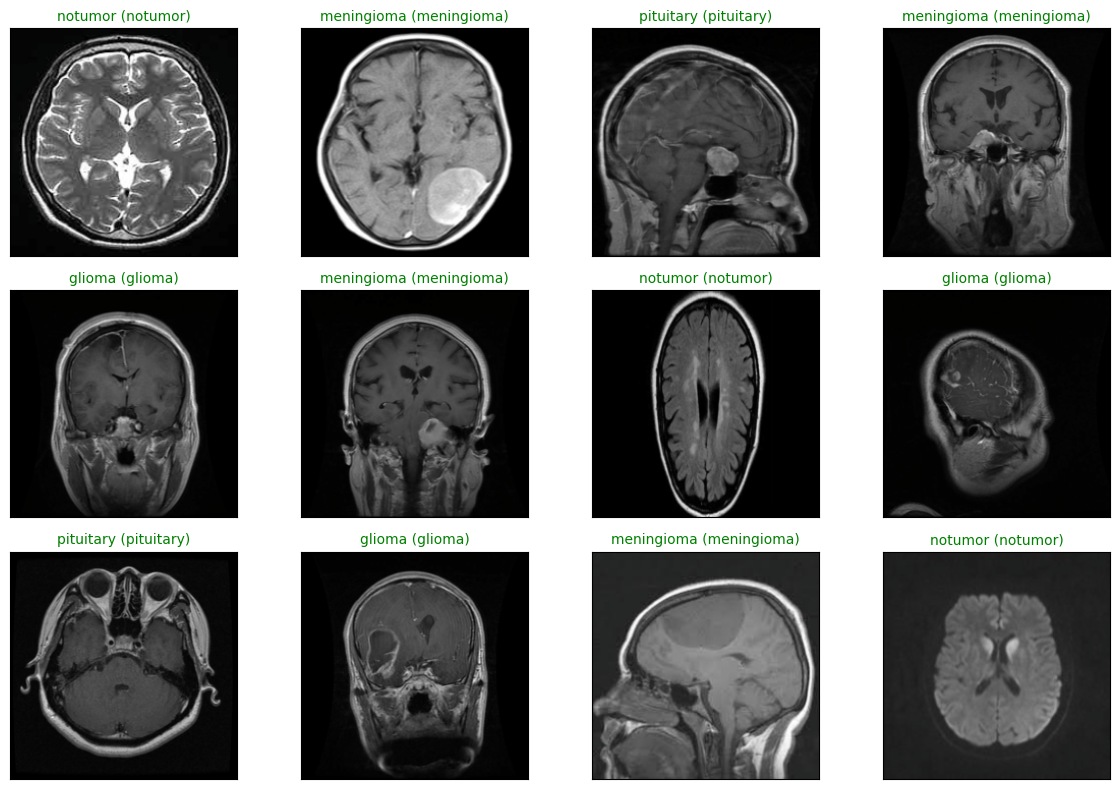

In [56]:
# --- Visual prediction grid (randomized batch) ---
vis_loader = DataLoader(test_data, batch_size=12, shuffle=True)

imgs, labels = next(iter(vis_loader))
imgs_dev = imgs.to(device)

model.eval()
with torch.no_grad():
    outputs = model(imgs_dev)
    preds = outputs.argmax(1).cpu().numpy()

imgs = imgs.numpy()
labels = labels.numpy()

fig = plt.figure(figsize=(12, 8))
for i in range(len(imgs)):
    ax = fig.add_subplot(3, 4, i+1, xticks=[], yticks=[])
    # denormalize for display
    img = imgs[i].transpose(1,2,0)  # C,H,W -> H,W,C
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    pred_label = classes[preds[i]]
    true_label = classes[labels[i]]
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"{pred_label} ({true_label})", color=color, fontsize=10)
plt.tight_layout()
plt.show()



## Tips & Extensions

- If results are still weak, train for more epochs, unfreeze more layers and reduce the learning rate.
- Try MixUp/CutMix or stronger augmentation if overfitting persists.
- Consider Focal Loss for class imbalance (`alpha`, `gamma` tuning).
- Upgrade backbone to ResNet50 or EfficientNet-B0 if you have GPU headroom.
